In [1]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations
import os

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import numpy as np
import pandas as pd
from multiprocessing import Pool

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorial relies on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

num_cpus = 5

### Load Hi-C cool files (1kb resolution)

In [2]:
clrs = {
    'Adult': cooler.Cooler('/tank/projects/kashuk_sirt6_hic/combined/bal_sampled_Adult_1k.cool'),
    'Old': cooler.Cooler('/tank/projects/kashuk_sirt6_hic/combined/bal_sampled_Old_1k.cool'),
    'S6-KO': cooler.Cooler('/tank/projects/kashuk_sirt6_hic/combined/bal_sampled_S6-KO_1k.cool')
}


### Load chromosome arms data

In [4]:
mm10_arms = pd.read_csv('mm10_arms.csv', index_col=0)
mm10_arms.head(5)

,chrom,start,end,name
0,chr1,0,195471971,chr1_p
1,chr2,0,182113224,chr2_p
2,chr3,0,160039680,chr3_p
3,chr4,0,156508116,chr4_p
4,chr5,0,151834684,chr5_p


### Calculate expected interactions per chromosome arm and aggregate scaling data

In [6]:
colors = {'Adult': 'tan', 'Old': 'sienna', 'S6-KO': 'grey'}

cvd_results = {}
slopes = {}

def process_cooler(clr, name):
    """Process Hi-C data to compute expected contacts and store results."""
    cvd_smooth_agg = cooltools.expected_cis(
        clr=clr,
        view_df=mm10_arms,
        smooth=True,
        aggregate_smoothed=True,
        smooth_sigma=0.1,
        nproc=num_cpus
    )
    
    cvd_smooth_agg['balanced.avg.smoothed.agg'].loc[cvd_smooth_agg['dist'] < 2] = np.nan
    cvd_merged = cvd_smooth_agg.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]
    cvd_results[name] = cvd_merged
    
    # Compute slope
    slopes[name] = np.gradient(np.log(cvd_merged['balanced.avg.smoothed.agg']), np.log(cvd_merged['dist_bp']))


In [7]:
for name, clr in clrs.items():
    process_cooler(clr, name)

INFO:root:creating a Pool of 5 workers
INFO:root:creating a Pool of 5 workers
INFO:root:creating a Pool of 5 workers


In [8]:
import pandas as pd

combined_df = pd.concat(
    [df.assign(condition=name) for name, df in cvd_results.items()],
    ignore_index=True
)

In [9]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


In [13]:
%%R
library(reticulate)
library(tidyverse)

cvd_combined <- reticulate::py_eval('combined_df')

cvd_slope <- cvd_combined %>%
  group_by(condition) %>%
  arrange(dist_bp) %>%
  mutate(
    log_dist = log(dist_bp),
    log_contact = log(balanced.avg.smoothed.agg),
    slope = c(NA, diff(log_contact) / diff(log_dist))
  ) %>%
  filter(!is.na(slope))
cvd_slope$condition <- factor(cvd_slope$condition, levels=c('Adult', 'Old', 'S6-KO'))


In [ ]:
## Adult slope:

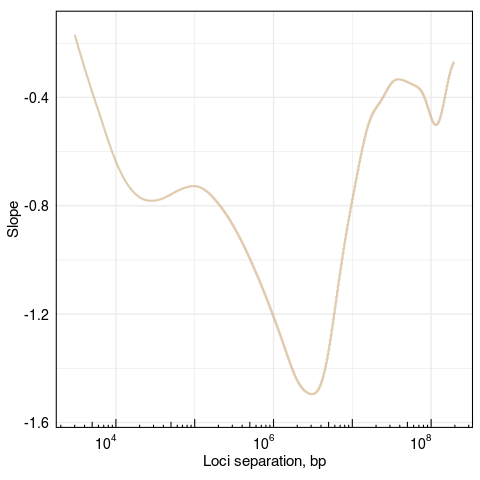

In [14]:
%%R

ggplot(cvd_slope %>% filter(condition == "Adult"), aes(x = dist_bp, y = slope, color = condition)) +
  geom_line(size = 1, alpha = 0.7, color='tan') +  
  ylim(-1.55, -0.15) +
  scale_x_log10(
    breaks = c(1e4, 1e6, 1e8),
    labels = c(
      expression(10^4), 
      expression(10^6), expression(10^8)
    )
  ) +
  annotation_logticks(sides = "b") +
  labs(
    x = "Loci separation, bp", 
    y = "Slope",                
    color = "Condition"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(size = 14, colour = "black", hjust = 1),
    axis.text.y = element_text(size = 14, colour = "black"),
    axis.title.x = element_text(size = 15, colour = "black"),
    axis.title.y = element_text(size = 15, colour = "black"),
    legend.position = "none",
    panel.border = element_rect(colour = "black", fill = NA, size = 1),
    aspect.ratio = 1
  )

In [ ]:
## Old slope:

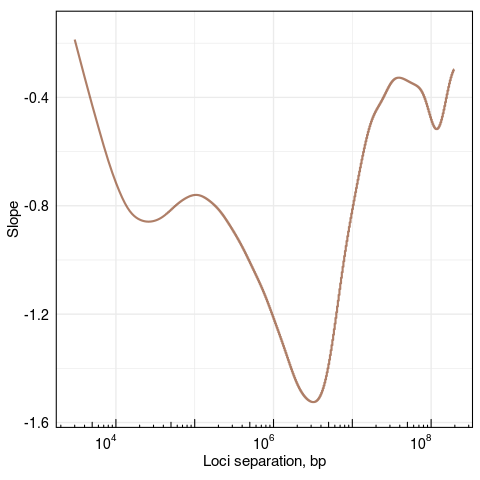

In [15]:
%%R

ggplot(cvd_slope %>% filter(condition == "Old"), aes(x = dist_bp, y = slope, color = condition)) +
  geom_line(size = 1, alpha = 0.7, color='sienna4') +  
  ylim(-1.55, -0.15) +
  scale_x_log10(
    breaks = c(1e4, 1e6, 1e8),
    labels = c(
      expression(10^4), 
      expression(10^6), expression(10^8)
    )
  ) +
  annotation_logticks(sides = "b") +
  labs(
    x = "Loci separation, bp", 
    y = "Slope",                
    color = "Condition"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(size = 14, colour = "black", hjust = 1),
    axis.text.y = element_text(size = 14, colour = "black"),
    axis.title.x = element_text(size = 15, colour = "black"),
    axis.title.y = element_text(size = 15, colour = "black"),
    legend.position = "none",
    panel.border = element_rect(colour = "black", fill = NA, size = 1),
    aspect.ratio = 1
  )

In [ ]:
## S6-KO slope:

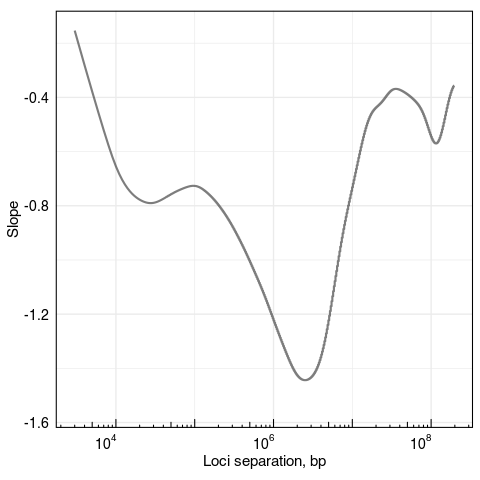

In [17]:
%%R

ggplot(cvd_slope %>% filter(condition == "S6-KO"), aes(x = dist_bp, y = slope, color = condition)) +
  geom_line(size = 1, alpha = 0.7, color='gray27') +  
  ylim(-1.55, -0.15) +
  scale_x_log10(
    breaks = c(1e4, 1e6, 1e8),
    labels = c(
      expression(10^4), 
      expression(10^6), expression(10^8)
    )
  ) +
  annotation_logticks(sides = "b") +
  labs(
    x = "Loci separation, bp", 
    y = "Slope",                
    color = "Condition"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(size = 14, colour = "black", hjust = 1),
    axis.text.y = element_text(size = 14, colour = "black"),
    axis.title.x = element_text(size = 15, colour = "black"),
    axis.title.y = element_text(size = 15, colour = "black"),
    legend.position = "none",
    panel.border = element_rect(colour = "black", fill = NA, size = 1),
    aspect.ratio = 1
  )